In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("floorplan_features_clean.csv")

df.head()

,plan_id,num_rooms,avg_room_area,std_room_area,avg_aspect_ratio,avg_compactness,avg_rectangularity,public_private_separation,service_area_ratio,bathroom_adjacency,...,mean_depth,integration,gross_area,usable_area,efficiency,corridor_ratio,rooms_with_window_ratio,external_wall_ratio,cross_ventilation_ratio,window_wall_ratio
0,1,0.375000,0.420636,0.467200,0.584963,0.219055,0.801671,0.0,0.428571,0.000000,...,0.000000,1.000000,0.391618,0.435084,0.864364,0.135636,0.482072,0.566366,0.000000,0.333106
1,4,0.000000,0.911412,0.795006,0.698474,0.095312,0.501409,0.0,0.600000,0.000000,...,0.000000,1.000000,0.206616,0.194469,0.408601,0.591399,0.596016,0.871498,0.000000,0.367460
2,16,0.500000,0.605564,0.490803,0.582480,0.698285,0.964496,0.0,0.352941,1.000000,...,0.000000,1.000000,0.655755,0.630664,0.330762,0.669238,0.850715,0.741037,0.282353,0.584483
3,17,0.250000,0.170899,0.185975,0.686689,0.565110,0.874281,0.0,0.545455,0.000000,...,0.416667,0.437500,0.147754,0.142342,0.524896,0.475104,0.637450,0.734248,0.000000,0.319924
4,22,0.458333,0.566965,0.645968,0.245127,0.844198,0.879302,0.0,0.375000,0.333333,...,0.208333,0.678571,0.580251,0.522163,0.126835,0.873165,0.410857,0.221704,0.000000,0.797946


In [3]:
df["E"] = (
    df["efficiency"] +
    (1 - df["corridor_ratio"]) +
    df["avg_room_area"]
) / 3

In [4]:
df["Z"] = (
    df["public_private_separation"] +
    df["bathroom_adjacency"] +
    (1 - df["service_area_ratio"])
) / 3

In [8]:
df["L"] = (
    df["rooms_with_window_ratio"] +
    df["cross_ventilation_ratio"] +
    df["window_wall_ratio"]
) / 3

In [5]:
df["P"] = (
    df["avg_compactness"] +
    df["avg_rectangularity"] +
    (1 - df["avg_aspect_ratio"])
) / 3

In [6]:
df["C"] = (
    df["integration"] +
    (1 - df["mean_depth"]) +
    (1 - df["avg_shortest_path"])
) / 3

In [9]:
df["DQI"] = (
    0.25 * df["E"] +
    0.20 * df["Z"] +
    0.20 * df["L"] +
    0.15 * df["P"] +
    0.20 * df["C"]
)

In [10]:
df["Score"] = df["DQI"] * 10

In [11]:
def categorize(score):

    if score < 4:
        return "Poor"
    
    elif score < 6:
        return "Average"
    
    elif score < 8:
        return "Good"
    
    else:
        return "Excellent"


df["quality_class"] = df["Score"].apply(categorize)

In [12]:
df[[
    "plan_id",
    "E",
    "Z",
    "L",
    "P",
    "C",
    "DQI",
    "Score",
    "quality_class"
]].head()

,plan_id,E,Z,L,P,C,DQI,Score,quality_class
0,1,0.716454,0.190476,0.271726,0.478587,1.000000,0.543342,5.433421,Average
1,4,0.576205,0.133333,0.321159,0.299416,1.000000,0.479862,4.798620,Average
2,16,0.422363,0.549020,0.572517,0.693433,1.000000,0.633913,6.339130,Good
3,17,0.406897,0.151515,0.319125,0.584234,0.534722,0.390432,3.904318,Poor
4,22,0.273545,0.319444,0.402934,0.826124,0.753968,0.487574,4.875743,Average


In [13]:
df.to_csv("dataset_with_dqi.csv", index=False)

print("DQI dataset saved successfully")

DQI dataset saved successfully


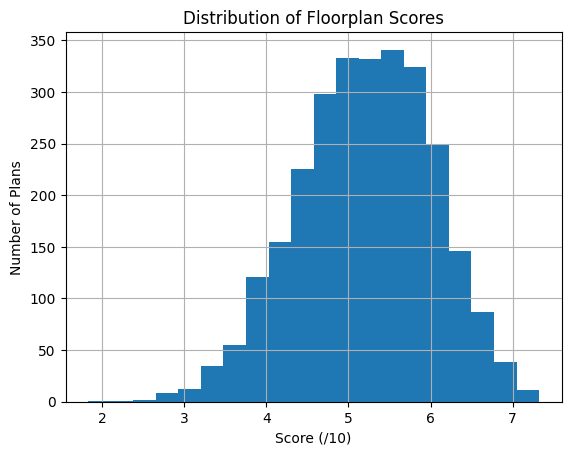

In [14]:
import matplotlib.pyplot as plt

df["Score"].hist(bins=20)

plt.title("Distribution of Floorplan Scores")
plt.xlabel("Score (/10)")
plt.ylabel("Number of Plans")
plt.show()